In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [119]:
df=pd.read_csv('/content/drive/MyDrive/disasterIND.csv')
df.head()

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,Entry Date,Last Update
0,1900-9001-IND,Yes,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,IND,...,NaN,NaN,NaN,NaN,NaN,NaN,2.730451,NaN,01-12-2006,25-09-2023
1,1905-0003-IND,Yes,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,IND,...,NaN,NaN,NaN,NaN,25000.0,847777.0,2.948887,NaN,01-07-2003,25-09-2023
2,1907-0001-IND,Yes,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,NaN,Bubonic,IND,...,NaN,NaN,NaN,NaN,NaN,NaN,3.058105,NaN,01-07-2003,25-09-2023
3,1916-0004-IND,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,IND,...,NaN,NaN,NaN,NaN,NaN,NaN,3.576717,NaN,01-07-2003,25-09-2023
4,1920-0001-IND,Yes,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,NaN,Bubonic,IND,...,NaN,NaN,NaN,NaN,NaN,NaN,6.562784,NaN,01-07-2003,25-09-2023


In [120]:
#Removing the unnecessary columns
newdf=df.drop(columns=[
    "Reconstruction Costs ('000 US$)",
    "Reconstruction Costs, Adjusted ('000 US$)",
    "Insured Damage ('000 US$)",
    "Insured Damage, Adjusted ('000 US$)",
    'River Basin',
    "AID Contribution ('000 US$)",
    "River Basin",
    "Admin Units",
    "Event Name",
    "ISO",
    "Country",
    "Subregion",
    "Region",
    'Classification Key',
    'Historic',
    'OFDA/BHA Response',
    'Appeal',
    'Declaration',
],axis=1)

In [ ]:
#Data Preprocessing

In [121]:
newdf['Magnitude']=df.groupby('Disaster Type')['Magnitude'].transform(lambda x:x.fillna(x.median()))

In [122]:
#There may be disaster types where all magnitudes are missing thus we cannot calculate median as there is no value
newdf['Magnitude']=newdf['Magnitude'].fillna(0)

In [123]:
#Now there are no missing values
print(newdf['Magnitude'].isnull().sum())

0


In [124]:
#Filling Missing Values with 15 (middle of the month) for start and end date because to avoid bias
newdf['Start Day']=newdf['Start Day'].fillna(15)
newdf['End Day']=newdf['End Day'].fillna(15)

In [125]:
newdf['Start Month']=newdf['Start Month'].fillna(6)
newdf['End Month']=newdf['End Month'].fillna(6)

In [126]:
#Creating a new Feature from the day,month and year column
newdf['Start Date']=pd.to_datetime(
    dict(year=newdf['Start Year'],month=newdf['Start Month'],day=newdf['Start Day'])
)
newdf[['Start Year','Start Month','Start Day','Start Date']]

,Start Year,Start Month,Start Day,Start Date
0,1900,6.0,15.0,1900-06-15
1,1905,4.0,4.0,1905-04-04
2,1907,6.0,15.0,1907-06-15
3,1916,11.0,21.0,1916-11-21
4,1920,6.0,15.0,1920-06-15
...,...,...,...,...
778,2024,5.0,15.0,2024-05-15
779,2024,7.0,9.0,2024-07-09
780,2024,7.0,31.0,2024-07-31
781,2024,8.0,19.0,2024-08-19


In [127]:
newdf['End Date']=pd.to_datetime(
    dict(year=newdf['End Year'],month=newdf['End Month'],day=newdf['End Day'])
)
newdf[['End Year','End Month','End Day','End Date']]

,End Year,End Month,End Day,End Date
0,1900,6.0,15.0,1900-06-15
1,1905,4.0,4.0,1905-04-04
2,1907,6.0,15.0,1907-06-15
3,1916,11.0,21.0,1916-11-21
4,1920,6.0,15.0,1920-06-15
...,...,...,...,...
778,2024,7.0,8.0,2024-07-08
779,2024,7.0,15.0,2024-07-15
780,2024,8.0,23.0,2024-08-23
781,2024,8.0,23.0,2024-08-23


In [128]:
#Calculate no. of days the diasaster lasted for
newdf['Duration(days)']=(newdf['End Date']-newdf['Start Date']).dt.days

In [129]:
#Select the rows where duration is negative with the column duration(days) and replace them with 0 in the dataframe
newdf.loc[newdf['Duration(days)']<0,'Duration(days)']=0


In [130]:
#Dropping some more unnecessary columns
drop_cols=['DisNo.','Entry Date','Last Update','External IDs']
newdf=newdf.drop(columns=drop_cols,axis=1)

/tmp/ipykernel_2483/3447907021.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(newdf['Total Deaths'])


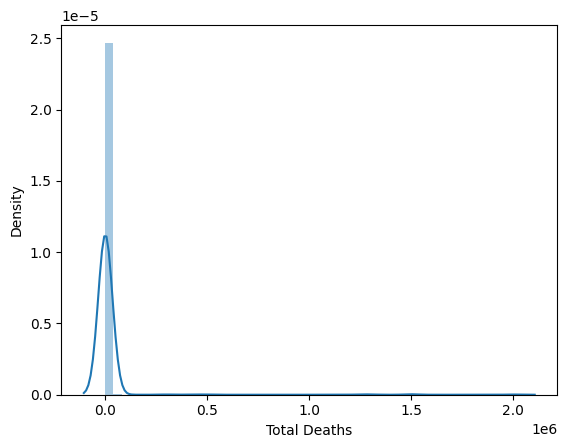

Skewness of Total Deaths: 11.806288343640151


In [131]:
sns.distplot(newdf['Total Deaths'])
plt.show()
print("Skewness of Total Deaths:",newdf['Total Deaths'].skew())

In [132]:
#Removing the row having null values in the Total Deaths column
newdf = newdf.dropna(subset=['Total Deaths'])
print(newdf['Total Deaths'].isnull().sum())

0


In [134]:
#Handling Outliers
upper=newdf['Total Deaths'].quantile(0.95)
df['Total Deaths'] = np.clip(df['Total Deaths'], 0, upper)

In [135]:
newdf['log_deaths']=np.log1p(newdf['Total Deaths'])

In [136]:
newdf['log_deaths']

,log_deaths
0,14.038655
1,9.903538
2,14.077876
3,5.707110
4,14.508658
...,...
778,3.891820
779,4.836282
780,3.850148
781,2.484907


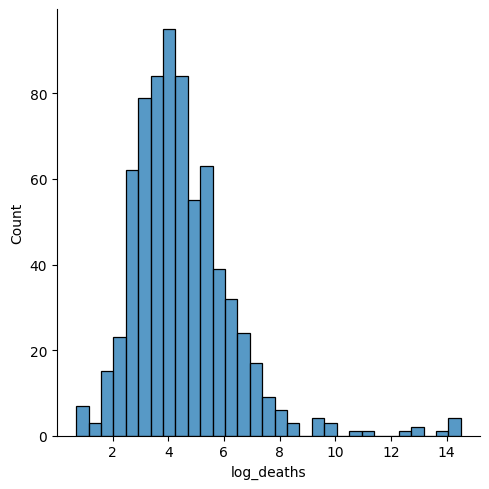

Skewness: 1.7649799450294914


In [137]:
sns.displot(newdf['log_deaths'])
plt.show()
print("Skewness:",newdf['log_deaths'].skew())

In [143]:
# Clean and fill in SAME dataframe (newdf)
newdf['Location'] = newdf['Location'].replace(['', 'nan', None], np.nan)
newdf['Location'] = newdf['Location'].fillna('Unknown')

# Now clean location
newdf['Cleaned_Location'] = newdf['Location'].str.split(',').str[0]

In [145]:
newdf["Cleaned_Location"] = newdf["Cleaned_Location"].replace({
    "West Begala": "West Bengal",
    "Western": "West",
    "Balasore":"Odisha",
    "Balasore (Baleshwar)":"Odisha",
    "Orissa":"Odisha",
    "Orissa (Orissa)":"Odisha",
    "Odisha province":"Odisha",
    "Odisha state":"Odisha",
    "Odisha, India":"Odisha",
    "Calcutta":"West Bengal",
    "West Bengal, India":"West Bengal",
    "Bengal":"West Bengal",
    "West Bengal province":"West Bengal",
    "West Bengal state":"West Bengal",
    "W Bengal":"West Bengal"
})

**Predicting Deaths using Regression**

In [146]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


#Define Features
features=['Magnitude','Start Month','Duration(days)','Disaster Type','Cleaned_Location','No. Injured','Total Affected']
# Use the log-transformed 'log_deaths' as the target variable
y=newdf['log_deaths']
# Create X after defining y, as X also contains columns that might be imputed/engineered
X=newdf[features]

#One Hot Encoding on the categorical features
X = pd.get_dummies(
    X,
    columns=['Disaster Type','Cleaned_Location'],
    drop_first=True
)

# Handle any NaN values in X that might still exist after feature engineering and one-hot encoding
X = X.fillna(X.mean(numeric_only=True))

#Performing Train Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=XGBRegressor(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_lambda=1
)

#Training the model
model.fit(X_train,y_train)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1500,
             n_jobs=None, num_parallel_tree=None, ...)

In [150]:
#Hyperparameter Tuning
param_grid = {
    'n_estimators':[200,300,500],
    'learning_rate':[0.03,0.05],
    'max_depth':[5,7,9],
    'subsample':[0.8,0.9],
}


# param_grid={
#     'n_estimators':[800,1200,1500],
#     'learning_rate':[0.01,0.02,0.03],
#     'max_depth':[6,8,10],
#     'subsample':[0.8,0.9],
#     'colsample_bytree':[0.8,0.9],
#     'gamma':[0.1,0.2]
# }

xgb=XGBRegressor(objective='reg:squarederror')

grid=GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

In [151]:
#Training the model
grid.fit(X_train,y_train)
best_model=grid.best_estimator_
print("Best Parameters:",grid.best_params_)
best_model.fit(X_train,y_train)

#Predicting the model
y_pred=best_model.predict(X_test)

#Clipping predictions to avoid exponential overflow
y_pred=np.clip(y_pred,-10,10)
#Reversing the log transform
y_pred=np.expm1(y_pred)
y_test=np.expm1(y_test)

#remove invalid values
y_pred = np.nan_to_num(y_pred)
y_test = np.nan_to_num(y_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.9}


In [153]:
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

print("MAE:",mean_absolute_error(y_test_real,y_pred_real))
print("RMSE:",np.sqrt(mean_squared_error(y_test_real,y_pred_real)))
print("R2:",r2_score(y_test_real,y_pred_real))

MAE: 114.70079803466797
RMSE: 255.55517078020551
R2: 0.17263519763946533


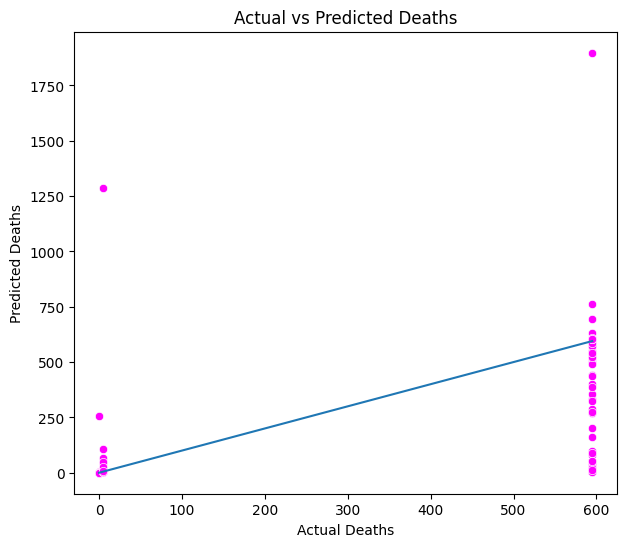

In [158]:
#Visualising the model performance
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test_real, y=y_pred_real,color='magenta')
plt.plot([y_test_real.min(), y_test_real.max()],[y_test_real.min(), y_test_real.max()])

plt.xlabel("Actual Deaths")
plt.ylabel("Predicted Deaths")
plt.title("Actual vs Predicted Deaths")

plt.show()

Predicting impact level of Deaths using Classification

In [35]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.3 MB/s eta 0:00:00


In [148]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from category_encoders import TargetEncoder

#Defining the features
features = [
    'Start Year',
    'Start Month',
    'Magnitude',
    'No. Injured',
    'No. Homeless',
    "Total Affected",
    "Total Damage ('000 US$)",
    'Disaster Type',
    'Disaster Subtype',
    'Location'
]

target = 'Total Deaths'
newdf = df[features + [target]].copy()

#Handled missing values
newdf.fillna(0, inplace=True)

#Feature Engineering
newdf['impact_ratio'] = newdf['No. Injured'] / (newdf['Total Affected'] + 1)
newdf['damage_per_person'] = newdf["Total Damage ('000 US$)"] / (newdf['Total Affected'] + 1)
newdf['year_trend'] = newdf['Start Year'] - newdf['Start Year'].min()
newdf['severity_index'] = newdf['Magnitude'] * (newdf['Total Affected'] + 1)
newdf['injury_ratio'] = newdf['No. Injured'] / (newdf['Total Affected'] + 1)

features += ['impact_ratio', 'damage_per_person', 'year_trend', 'severity_index', 'injury_ratio']

#Categorizing death level
newdf['death_category'] = pd.cut(
    newdf['Total Deaths'],
    bins=[-1, 10, 100, np.inf],
    labels=['Low', 'Medium', 'High']
)

X = newdf[features].copy()
y = newdf['death_category'].cat.codes # Convert categorical labels to numerical codes

#Encoding categorical features
cat_cols = ['Disaster Type', 'Disaster Subtype', 'Location']

encoder = TargetEncoder(cols=cat_cols)
X[cat_cols] = encoder.fit_transform(X[cat_cols], newdf['Total Deaths'])

#Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

#Hyperparameter Tuning
param_grid = {
    'max_depth': [5, 6, 7],
    'learning_rate': [0.03, 0.05],
    'n_estimators': [300, 500]
}

grid = GridSearchCV(
    XGBClassifier(
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train, y_train)
model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

#Predicting after training
y_pred = model.predict(X_test)



Best Parameters: {'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 300}



MODEL PERFORMANCE
Accuracy: 0.8471337579617835
F1 Score: 0.8466553698789863

Classification Report:

              precision    recall  f1-score   support

         Low       0.95      0.78      0.86        23
      Medium       0.83      0.90      0.86        80
        High       0.84      0.80      0.82        54

    accuracy                           0.85       157
   macro avg       0.87      0.83      0.85       157
weighted avg       0.85      0.85      0.85       157



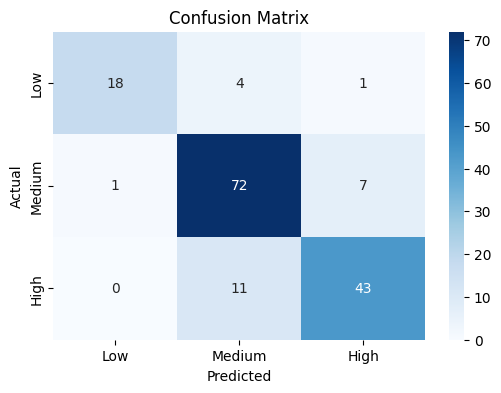

In [149]:
#Evaluating Models Performance
print("\nMODEL PERFORMANCE")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()